<a href="https://www.kaggle.com/code/sonawanelalitsunil/fraud-detection-ml-95-21?scriptVersionId=227814574" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fraud-detection-dataset-csv/Fraud Detection Dataset.csv


## Title : Fraud Detection

## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv('/kaggle/input/fraud-detection-dataset-csv/Fraud Detection Dataset.csv')

In [4]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [5]:
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [7]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [8]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [9]:
df.duplicated().sum()

881

In [10]:
df.dtypes

Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object

In [11]:
for col in df.columns:
    if df[col].dtype == 'object':  
        df[col] = df[col].fillna('Unknown')  
    else:  
        df[col] = df[col].fillna(df[col].mean())

In [12]:
df.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [13]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

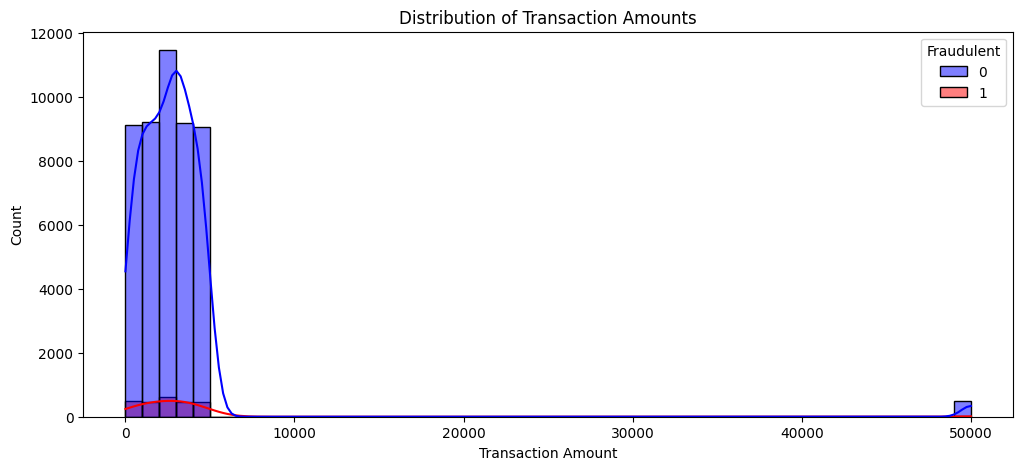

In [14]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Transaction_Amount', bins=50, kde=True, hue='Fraudulent', palette={0: 'blue', 1: 'red'})
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()


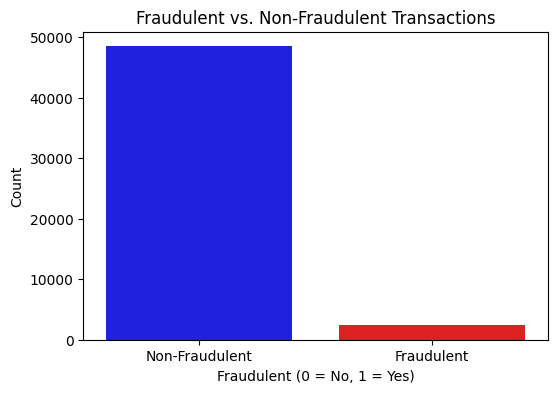

In [15]:
# 2. Fraudulent vs Non-Fraudulent Transactions
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Fraudulent'], palette={0: 'blue', 1: 'red'})
plt.title("Fraudulent vs. Non-Fraudulent Transactions")
plt.xlabel("Fraudulent (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Non-Fraudulent", "Fraudulent"])
plt.show()

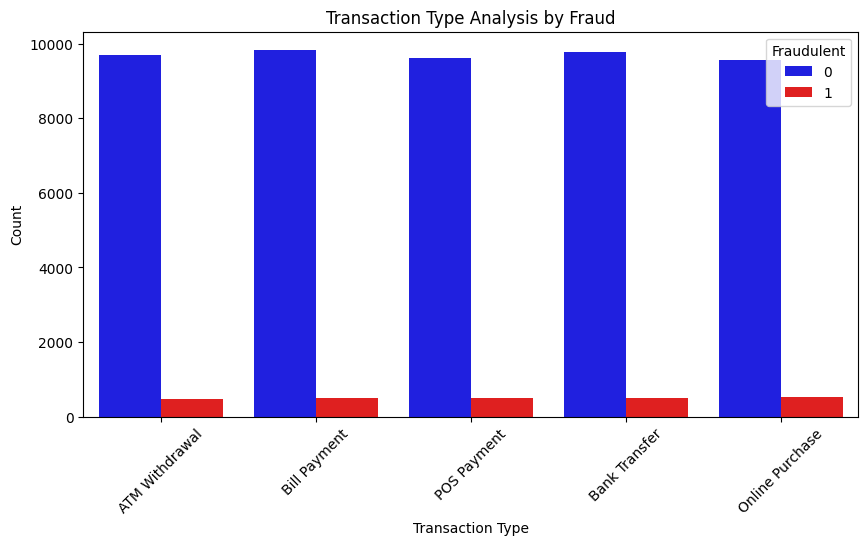

In [16]:
# 3. Transaction Type Analysis
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Transaction_Type", hue="Fraudulent", palette={0: 'blue', 1: 'red'})
plt.title("Transaction Type Analysis by Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

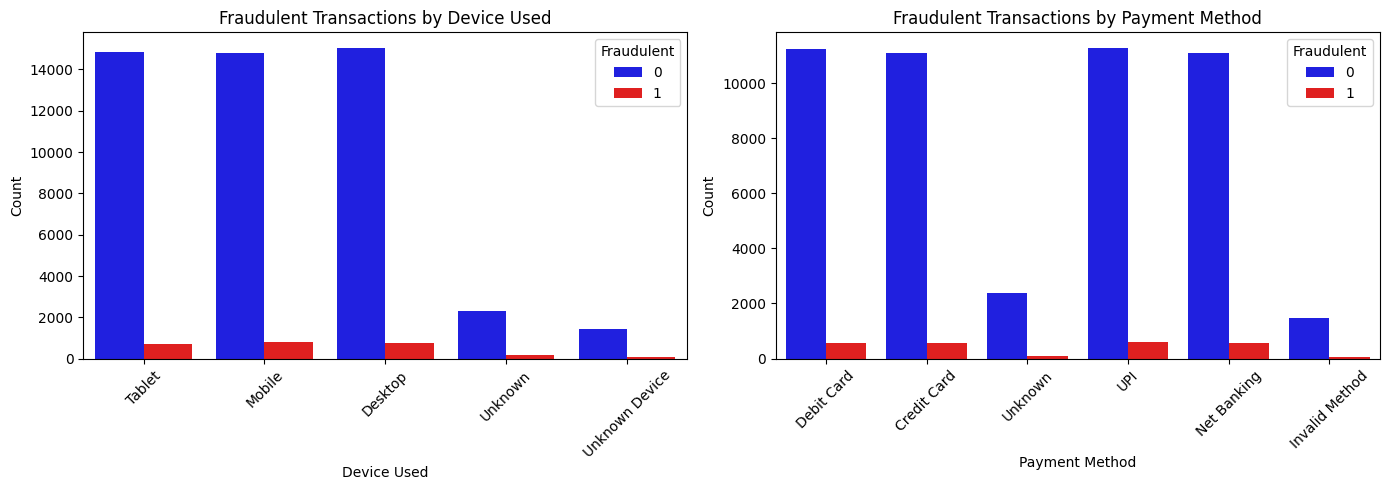

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Device_Used", hue="Fraudulent", palette={0: 'blue', 1: 'red'}, ax=axes[0])
axes[0].set_title("Fraudulent Transactions by Device Used")
axes[0].set_xlabel("Device Used")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x="Payment_Method", hue="Fraudulent", palette={0: 'blue', 1: 'red'}, ax=axes[1])
axes[1].set_title("Fraudulent Transactions by Payment Method")
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

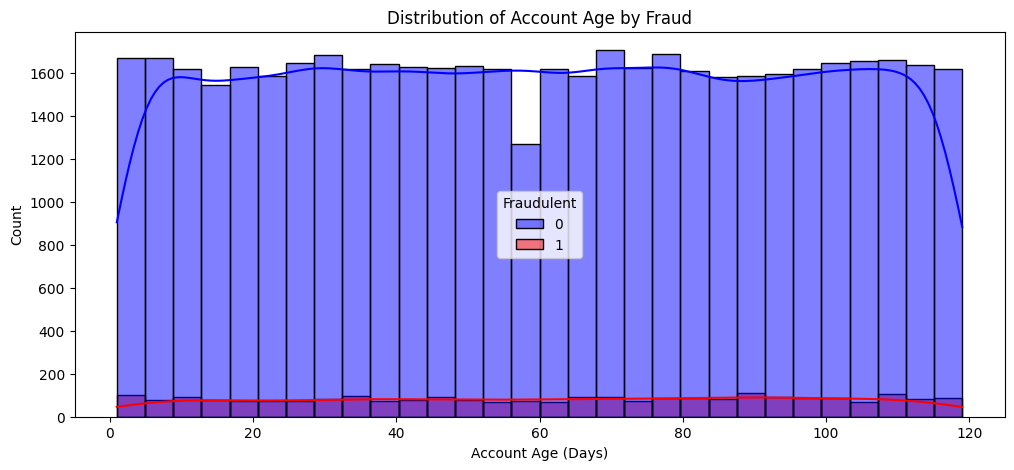

In [18]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Account_Age', bins=30, hue='Fraudulent', palette={0: 'blue', 1: 'red'}, kde=True)
plt.title("Distribution of Account Age by Fraud")
plt.xlabel("Account Age (Days)")
plt.ylabel("Count")
plt.show()


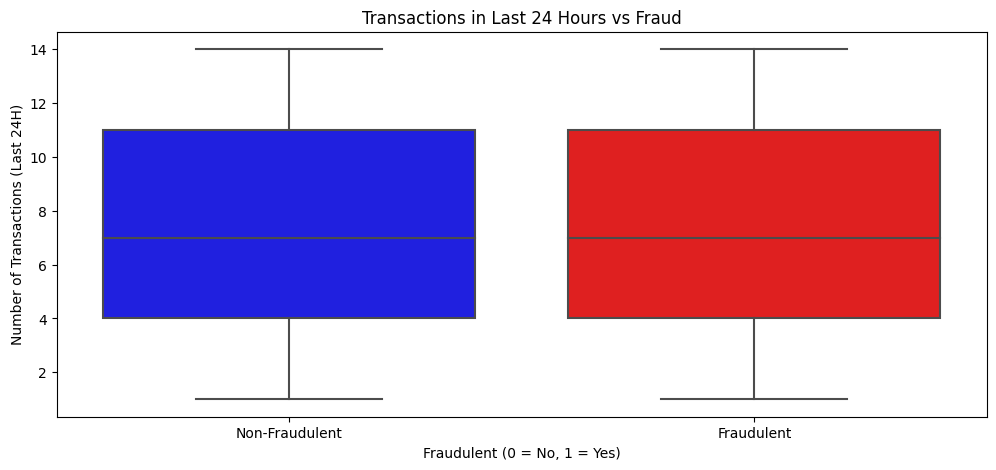

In [19]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="Fraudulent", y="Number_of_Transactions_Last_24H", palette={0: 'blue', 1: 'red'})
plt.title("Transactions in Last 24 Hours vs Fraud")
plt.xlabel("Fraudulent (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions (Last 24H)")
plt.xticks(ticks=[0, 1], labels=["Non-Fraudulent", "Fraudulent"])
plt.show()

## predictive Modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [21]:
df = df.drop(columns=['Transaction_ID', 'User_ID', 'Time_of_Transaction'])

In [22]:
# Label Encoding for categorical variables
label_encoders = {}
categorical_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

In [23]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [24]:
X = df.drop(columns=['Fraudulent'])  # Features
y = df['Fraudulent'] 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

In [27]:
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = acc

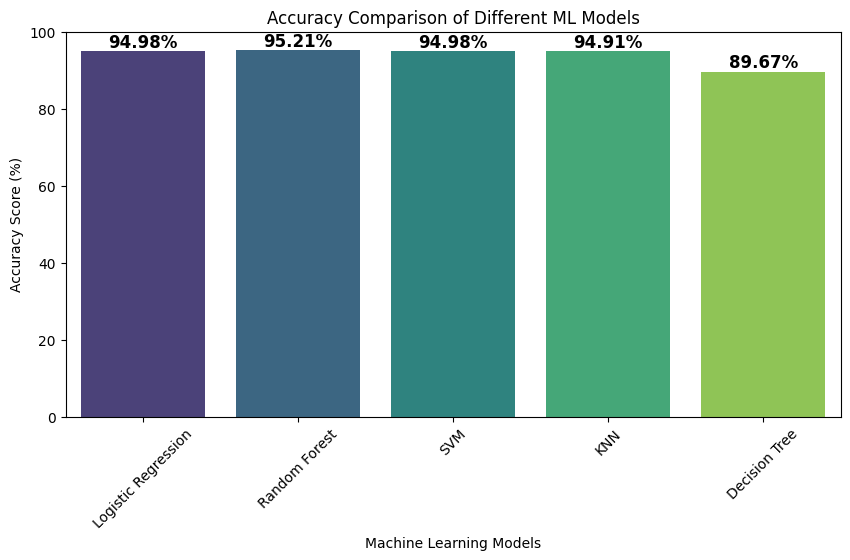

In [28]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    accuracy_scores[name] = acc

# Visualizing the Accuracy Scores in Percentage
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="viridis")

# Annotate bars with accuracy percentages
for index, value in enumerate(accuracy_scores.values()):
    plt.text(index, value + 1, f"{value:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score (%)")
plt.title("Accuracy Comparison of Different ML Models")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

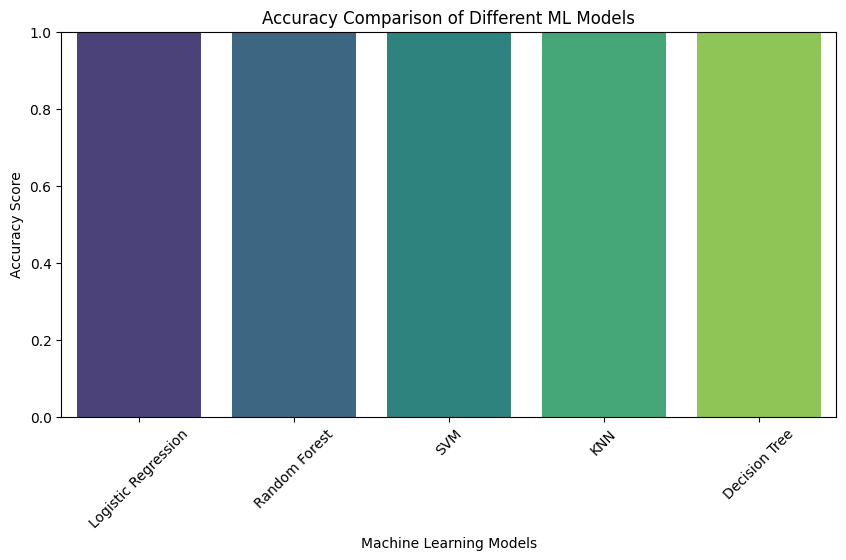

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="viridis")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.title("Accuracy Comparison of Different ML Models")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

## Thank you!!...pls upvote!!